# Fuzzy Logic Models — Leave-One-Out Cross-Validation (LOOCV)

## 1. Introduction and purpose

The three fuzzy logic notebooks in this folder
([`01a_fuzzy_BMWP`](01a_fuzzy_BMWP.ipynb),
[`01b_fuzzy_Perlidae`](01b_fuzzy_Perlidae.ipynb),
[`01c_fuzzy_Helicopsychidae`](01c_fuzzy_Helicopsychidae.ipynb))
evaluate their models **in sample**: the fuzzy rule base is generated from every
observation and then the very same observations are used to measure performance.
As stated in the Limitations of those notebooks, the resulting metrics describe
*fit*, not *generalisation*.

This notebook re-evaluates the same three Mamdani fuzzy systems under
**Leave-One-Out Cross-Validation (LOOCV)**. In each fold the rule base is built
from `n − 1` observations and the single held-out observation is predicted by a
rule base that never saw it. This is the honest test of whether the fuzzy models
generalise.

Two deliberate differences from the original notebooks:

1. **No outlier removal — all 18 observations are used.** The original notebooks
   trimmed the data to `n = 14` with an IQR rule (`margin = 2.5`). Here we keep all
   `n = 18` records so the fuzzy models are evaluated on the *same* sample size as
   the logistic-regression, classification-tree and negative-binomial models,
   which all used `n = 18`. This makes the cross-model comparison fair.
2. **Membership-function universes are extended** to cover the wider range of the
   full sample (see Section 3).

The original in-sample results (`n = 14`) are reproduced here as a baseline so the
two evaluation regimes can be compared directly in Section 7.

## 2. Dependencies and data loading

We load the two source datasets in full (no outlier removal). `DB - Macroinvertebrados.xlsx`
feeds the Perlidae and Helicopsychidae models; `Database - BMWP.xlsx` feeds the BMWP
model. Column names are kept exactly as in the data files (e.g. `DBO5`, `OD`,
`Turbiedad`, `Conductividad`, `SDT`, `Perlidae`, `Trichoptera`, `BMWP`).

In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import functools, operator
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score,
                             cohen_kappa_score, confusion_matrix, classification_report)
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")  # skfuzzy/sklearn emit many benign warnings on this tiny dataset

In [2]:
# Load both datasets in full (all 18 observations, no outlier removal)
macro_df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
macro_df.columns = macro_df.columns.str.strip()   # strip stray whitespace in headers
bmwp_df = pd.read_excel("../../data/Database - BMWP.xlsx")
bmwp_df.columns = bmwp_df.columns.str.strip()

# The five physicochemical predictors shared by all three fuzzy models
input_cols = ['DBO5', 'OD', 'Turbiedad', 'Conductividad', 'SDT']

print("Macroinvertebrate dataset:", macro_df.shape, "| Perlidae +:",
      int(macro_df['Perlidae'].sum()), "| Trichoptera +:", int(macro_df['Trichoptera'].sum()))
print("BMWP dataset:", bmwp_df.shape, "| BMWP range:",
      bmwp_df['BMWP'].min(), "-", bmwp_df['BMWP'].max())

Macroinvertebrate dataset: (18, 24) | Perlidae +: 6 | Trichoptera +: 3
BMWP dataset: (18, 24) | BMWP range: 9 - 116


## 3. Membership function definitions

The membership functions reuse **exactly the same interior breakpoints** as the
original notebooks. The only change is at the extremes: because the full
`n = 18` sample contains values that lie far outside the trimmed `n = 14` range
(for example `DBO5` reaches 35 mg/L vs. an original universe that stopped at 9.1,
and `Conductividad` reaches 766 µS/cm vs. an original maximum of 501), the
**universes are widened and the outermost category of each variable is turned into
a shoulder** (a `trapmf`) so that extreme observations still receive a sensible
membership instead of falling outside the universe.

Why the ranges differ from the originals: the original universes were sized for the
*outlier-removed* data. Re-using them on the full sample would push the most
polluted stations outside every membership function, which would turn genuine
*model* coverage failures (no rule for a category combination) into spurious
*numerical* failures (input outside the universe). Widening the universes isolates
the effect we actually want to measure — rule coverage under LOOCV.

We therefore define **two configurations**:

* `CONFIG_ORIGINAL` — the exact original universes / `trimf` parameters, used to
  reproduce the in-sample baseline on `n = 14`.
* `CONFIG_EXTENDED` — the widened universes / shoulder functions, used for the
  LOOCV on `n = 18`.

In [3]:
# Show the real data range of each predictor across all 18 observations.
# This is the evidence used to size the extended universes below.
ranges = pd.DataFrame({
    'min': macro_df[input_cols].min(),
    'max': macro_df[input_cols].max(),
}).round(2)
print("Predictor ranges over the full n=18 sample:")
print(ranges)

Predictor ranges over the full n=18 sample:
                min     max
DBO5            2.0   35.00
OD              3.2    7.69
Turbiedad       2.0   88.10
Conductividad  80.0  766.00
SDT            50.0  410.00


In [4]:
# CONFIG_ORIGINAL: exact membership functions from notebooks 01a/01b/01c (n=14 universes).
# Each term is (function_name, [parameters]); 'trimf' = triangular.
CONFIG_ORIGINAL = {
    'inputs': {
        'DBO5':          {'universe': (0, 9.1, 0.1),
                          'terms': {'Bajo': ('trimf', [0, 2, 3]),
                                    'Medio': ('trimf', [2.5, 4, 6]),
                                    'Alto': ('trimf', [5, 7, 9])}},
        'OD':            {'universe': (5, 7.6, 0.1),
                          'terms': {'Bajo': ('trimf', [4, 5, 5.8]),
                                    'Medio': ('trimf', [5.5, 6.3, 6.9]),
                                    'Alto': ('trimf', [6.5, 7, 7.5])}},
        'Turbiedad':     {'universe': (0, 31.1, 0.1),
                          'terms': {'Baja': ('trimf', [0, 2, 5]),
                                    'Media': ('trimf', [4, 8, 12]),
                                    'Alta': ('trimf', [10, 20, 31])}},
        'Conductividad': {'universe': (50, 501, 1),
                          'terms': {'Baja': ('trimf', [50, 80, 150]),
                                    'Media': ('trimf', [100, 250, 400]),
                                    'Alta': ('trimf', [300, 450, 500])}},
        'SDT':           {'universe': (30, 131, 1),
                          'terms': {'Bajo': ('trimf', [30, 50, 70]),
                                    'Medio': ('trimf', [60, 90, 110]),
                                    'Alto': ('trimf', [100, 120, 130])}},
    },
    'bmwp_output': {'name': 'bmwp', 'universe': (0, 121, 1),
                    'terms': {'Muy crítica': ('trimf', [0, 0, 15]),
                              'Crítica': ('trimf', [15, 35, 35]),
                              'Dudosa': ('trimf', [36, 60, 60]),
                              'Aceptable': ('trimf', [61, 100, 100]),
                              'Buena': ('trimf', [101, 120, 120])}},
    'binary_output': {'universe': (0, 1.1, 0.1),
                      'terms': {'Ausente': ('trimf', [0, 0, 0.5]),
                                'Presente': ('trimf', [0.5, 1, 1])}},
}

In [5]:
# CONFIG_EXTENDED: same interior breakpoints, widened universes, and the outermost
# category of every predictor extended into a shoulder ('trapmf' [a,b,c,d]) so that
# the full n=18 range is covered. Only the outer edges change vs CONFIG_ORIGINAL.
CONFIG_EXTENDED = {
    'inputs': {
        'DBO5':          {'universe': (0, 36, 0.1),        # data max 35
                          'terms': {'Bajo': ('trimf', [0, 2, 3]),
                                    'Medio': ('trimf', [2.5, 4, 6]),
                                    'Alto': ('trapmf', [5, 7, 36, 36])}},   # high shoulder
        'OD':            {'universe': (3, 7.8, 0.1),       # data min 3.2, max 7.69
                          'terms': {'Bajo': ('trapmf', [3, 3, 5, 5.8]),     # low shoulder
                                    'Medio': ('trimf', [5.5, 6.3, 6.9]),
                                    'Alto': ('trapmf', [6.5, 7, 7.8, 7.8])}},  # high shoulder
        'Turbiedad':     {'universe': (0, 89, 0.1),        # data max 88.1
                          'terms': {'Baja': ('trimf', [0, 2, 5]),
                                    'Media': ('trimf', [4, 8, 12]),
                                    'Alta': ('trapmf', [10, 20, 89, 89])}},
        'Conductividad': {'universe': (50, 770, 1),        # data max 766
                          'terms': {'Baja': ('trimf', [50, 80, 150]),
                                    'Media': ('trimf', [100, 250, 400]),
                                    'Alta': ('trapmf', [300, 450, 770, 770])}},
        'SDT':           {'universe': (30, 412, 1),        # data max 410
                          'terms': {'Bajo': ('trimf', [30, 50, 70]),
                                    'Medio': ('trimf', [60, 90, 110]),
                                    'Alto': ('trapmf', [100, 120, 412, 412])}},
    },
    # The output ranges already cover the data, so they are unchanged from the originals.
    'bmwp_output': CONFIG_ORIGINAL['bmwp_output'],
    'binary_output': CONFIG_ORIGINAL['binary_output'],
}

In [6]:
# Builder: turn a configuration dict into skfuzzy Antecedent objects and a Consequent.
# 'output_kind' selects which output to attach ('bmwp_output' or 'binary_output').
def make_io(config, output_kind, output_name):
    antecedents = {}
    for name, spec in config['inputs'].items():
        universe = np.arange(*spec['universe'])
        ant = ctrl.Antecedent(universe, name)
        for label, (kind, params) in spec['terms'].items():
            ant[label] = getattr(fuzz, kind)(universe, params)  # trimf or trapmf
        antecedents[name] = ant
    ospec = config[output_kind]
    ouniverse = np.arange(*ospec['universe'])
    consequent = ctrl.Consequent(ouniverse, output_name)
    for label, (kind, params) in ospec['terms'].items():
        consequent[label] = getattr(fuzz, kind)(ouniverse, params)
    return antecedents, consequent

In [7]:
# Generic fuzzy helpers shared by the in-sample and LOOCV routines.

# Assign a crisp value to the linguistic label with the highest membership degree.
def categorize_label(value, variable):
    degrees = {label: fuzz.interp_membership(variable.universe, variable[label].mf, value)
               for label in variable.terms}
    return max(degrees, key=degrees.get)

# Build the AND-conjoined antecedent for one observation across all predictors.
def build_antecedent(row, antecedents, cols):
    terms = [antecedents[c][categorize_label(row[c], antecedents[c])] for c in cols]
    return functools.reduce(operator.and_, terms)  # var1[..] & var2[..] & ...

In [8]:
# In-sample evaluation: build one rule per observation from ALL observations,
# then predict every observation with that full rule base (reproduces 01a/01b/01c).
def run_insample(df, cols, antecedents, consequent, output_name,
                 consequent_term_fn, true_label_fn, predict_label_fn):
    rules = [ctrl.Rule(build_antecedent(r, antecedents, cols), consequent_term_fn(r))
             for _, r in df.iterrows()]
    sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
    y_true, y_pred, crisp = [], [], []
    for _, r in df.iterrows():
        for c in cols:
            # Enter each observation as its dominant linguistic category, exactly as
            # notebooks 01a/01b/01c do (skfuzzy reads the label as full membership in
            # that set). This reproduces the original in-sample evaluation faithfully.
            sim.input[c] = categorize_label(r[c], antecedents[c])
        sim.compute()
        out = sim.output[output_name]
        crisp.append(out)
        y_pred.append(predict_label_fn(out))
        y_true.append(true_label_fn(r))
    return {'y_true': y_true, 'y_pred': y_pred, 'crisp': crisp, 'failed': []}

In [9]:
# LOOCV evaluation: for each fold, build the rule base from the n-1 training rows
# only, then predict the single held-out row. The held-out row never contributes a
# rule. A fold that no rule covers is recorded as a coverage failure ('No coverage').
def run_loocv(df, cols, antecedents, consequent, output_name,
              consequent_term_fn, true_label_fn, predict_label_fn, numeric_col=None):
    loo = LeaveOneOut()
    y_true, y_pred, failed = [], [], []
    crisp_ok, numeric_ok = [], []   # successful folds only (used for BMWP Spearman)
    for fold, (train_idx, test_idx) in enumerate(loo.split(df)):
        df_train = df.iloc[train_idx]            # n-1 observations
        df_test = df.iloc[test_idx]              # 1 held-out observation
        test_row = df_test.iloc[0]
        true_lbl = true_label_fn(test_row)

        # Rules generated ONLY from the training observations
        rules = [ctrl.Rule(build_antecedent(row, antecedents, cols), consequent_term_fn(row))
                 for _, row in df_train.iterrows()]
        fold_sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))

        try:
            for c in cols:
                # Held-out station fed as its raw crisp measurement, so the fuzzy
                # system uses its full graded (partial-membership) inference on the
                # unseen point. A fold still fails when no training rule fires at all.
                fold_sim.input[c] = test_row[c]
            fold_sim.compute()                   # raises if no rule fires (sparse system)
            out = fold_sim.output[output_name]
            y_pred.append(predict_label_fn(out))
            y_true.append(true_lbl)
            crisp_ok.append(out)
            if numeric_col is not None:
                numeric_ok.append(test_row[numeric_col])
        except Exception as e:                   # coverage failure -> counted as incorrect
            failed.append({'fold': fold, 'reason': str(e), 'test_obs': df_test.to_dict()})
            y_pred.append('No coverage')
            y_true.append(true_lbl)
    return {'y_true': y_true, 'y_pred': y_pred, 'failed': failed,
            'crisp_ok': crisp_ok, 'numeric_ok': numeric_ok}

In [10]:
# Metric helper. Macro-averaged precision/recall/F1 are computed over the substantive
# classes only; coverage failures ('No coverage') are NOT a class but still lower
# recall (a held-out true class predicted 'No coverage' is a miss) and overall
# accuracy. Cohen's kappa uses the full label union, so failures penalise it too.
def compute_metrics(y_true, y_pred, real_classes):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=real_classes, average='macro', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    try:
        kappa = cohen_kappa_score(y_true, y_pred)
    except Exception:
        kappa = np.nan
    return {'precision': p, 'recall': r, 'f1': f, 'accuracy': acc, 'kappa': kappa}

# Plot a confusion matrix; the 'No coverage' column is shown when failures occur.
def plot_cm(y_true, y_pred, real_classes, title, cmap):
    labels = list(real_classes) + (['No coverage'] if 'No coverage' in y_pred else [])
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(1.4 * len(labels) + 1.5, 1.2 * len(real_classes) + 1.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels, annot_kws={"size": 13})
    plt.xlabel("Predicted")
    plt.ylabel("Real")
    plt.title(title)
    plt.tight_layout()
    plt.show()

BMWP_ORDER = ['Muy crítica', 'Crítica', 'Dudosa', 'Aceptable', 'Buena']

## 4. LOOCV implementation — Model 1: BMWP

Reproduces the fuzzy system of [`01a_fuzzy_BMWP`](01a_fuzzy_BMWP.ipynb) (five
predictors → BMWP class) but under LOOCV on `n = 18`. The defuzzified BMWP value of
each held-out station is re-categorised into one of the five BMWP/Col classes and
compared with the observed class. For BMWP we additionally report Spearman's rank
correlation between the predicted crisp BMWP and the observed BMWP, computed over
the folds that produced an output.

In [11]:
# Build the extended (n=18) fuzzy I/O for BMWP and define the label callbacks
bmwp_ants, bmwp_cons = make_io(CONFIG_EXTENDED, 'bmwp_output', 'bmwp')

def bmwp_true(row):   return categorize_label(row['BMWP'], bmwp_cons)   # observed -> class
def bmwp_pred(out):   return categorize_label(out, bmwp_cons)           # crisp -> class
def bmwp_consequent(row): return bmwp_cons[categorize_label(row['BMWP'], bmwp_cons)]

# Run LOOCV for the BMWP model
bmwp_loocv = run_loocv(bmwp_df, input_cols, bmwp_ants, bmwp_cons, 'bmwp',
                       bmwp_consequent, bmwp_true, bmwp_pred, numeric_col='BMWP')

# Substantive classes actually observed, in canonical order
bmwp_classes = [c for c in BMWP_ORDER if c in bmwp_loocv['y_true']]
bmwp_loocv_m = compute_metrics(bmwp_loocv['y_true'], bmwp_loocv['y_pred'], bmwp_classes)

print(f"BMWP LOOCV   accuracy={bmwp_loocv_m['accuracy']:.3f}  kappa={bmwp_loocv_m['kappa']:.3f}")
print(f"coverage failures: {len(bmwp_loocv['failed'])} of {len(bmwp_df)} "
      f"({100*len(bmwp_loocv['failed'])/len(bmwp_df):.0f}%)")
print("\nClassification report (LOOCV):")
report_labels = bmwp_classes + (['No coverage'] if 'No coverage' in bmwp_loocv['y_pred'] else [])
print(classification_report(bmwp_loocv['y_true'], bmwp_loocv['y_pred'],
                            labels=report_labels, zero_division=0))

BMWP LOOCV   accuracy=0.222  kappa=0.077
coverage failures: 11 of 18 (61%)

Classification report (LOOCV):
              precision    recall  f1-score   support

 Muy crítica       0.00      0.00      0.00         2
     Crítica       0.00      0.00      0.00         3
      Dudosa       0.00      0.00      0.00         4
   Aceptable       0.67      0.50      0.57         8
       Buena       0.00      0.00      0.00         1
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.22        18
   macro avg       0.11      0.08      0.10        18
weighted avg       0.30      0.22      0.25        18



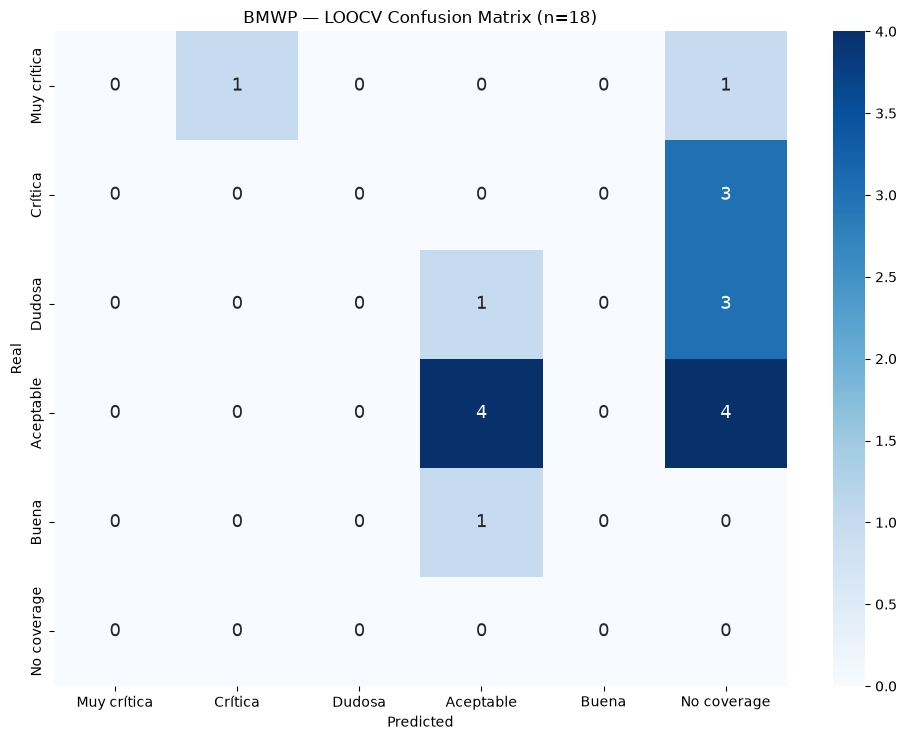

In [12]:
# Confusion matrix for the BMWP LOOCV predictions
plot_cm(bmwp_loocv['y_true'], bmwp_loocv['y_pred'], bmwp_classes,
        "BMWP — LOOCV Confusion Matrix (n=18)", "Blues")

In [13]:
# Spearman correlation between predicted crisp BMWP and observed BMWP (successful folds)
if len(bmwp_loocv['crisp_ok']) >= 3:
    rs, p_value = spearmanr(bmwp_loocv['numeric_ok'], bmwp_loocv['crisp_ok'])
    print(f"BMWP LOOCV Spearman r_s = {rs:.3f} (p = {p_value:.4g}) "
          f"over {len(bmwp_loocv['crisp_ok'])} folds with output")
else:
    rs = np.nan
    print("Not enough successful folds to compute Spearman correlation.")

BMWP LOOCV Spearman r_s = 0.143 (p = 0.7599) over 7 folds with output


## 5. LOOCV implementation — Model 2: Perlidae

Reproduces the binary presence/absence fuzzy system of
[`01b_fuzzy_Perlidae`](01b_fuzzy_Perlidae.ipynb) under LOOCV on `n = 18`. A
defuzzified output `≥ 0.499` is read as *Present* (the threshold used in the
original notebook).

In [14]:
# Build extended fuzzy I/O for Perlidae and define the binary label callbacks
perlidae_ants, perlidae_cons = make_io(CONFIG_EXTENDED, 'binary_output', 'Perlidae')
PERLIDAE_THR = 0.499   # threshold used in 01b_fuzzy_Perlidae

def perlidae_true(row):   return 'Presente' if row['Perlidae'] == 1 else 'Ausente'
def perlidae_pred(out):   return 'Presente' if out >= PERLIDAE_THR else 'Ausente'
def perlidae_consequent(row):
    return perlidae_cons['Presente'] if row['Perlidae'] == 1 else perlidae_cons['Ausente']

# Run LOOCV for the Perlidae model
perlidae_loocv = run_loocv(macro_df, input_cols, perlidae_ants, perlidae_cons, 'Perlidae',
                           perlidae_consequent, perlidae_true, perlidae_pred)

perlidae_classes = ['Ausente', 'Presente']
perlidae_loocv_m = compute_metrics(perlidae_loocv['y_true'], perlidae_loocv['y_pred'], perlidae_classes)

print(f"Perlidae LOOCV  accuracy={perlidae_loocv_m['accuracy']:.3f}  kappa={perlidae_loocv_m['kappa']:.3f}")
print(f"coverage failures: {len(perlidae_loocv['failed'])} of {len(macro_df)} "
      f"({100*len(perlidae_loocv['failed'])/len(macro_df):.0f}%)")
print("\nClassification report (LOOCV):")
report_labels = perlidae_classes + (['No coverage'] if 'No coverage' in perlidae_loocv['y_pred'] else [])
print(classification_report(perlidae_loocv['y_true'], perlidae_loocv['y_pred'],
                            labels=report_labels, zero_division=0))

Perlidae LOOCV  accuracy=0.222  kappa=0.067
coverage failures: 11 of 18 (61%)

Classification report (LOOCV):
              precision    recall  f1-score   support

     Ausente       0.50      0.08      0.14        12
    Presente       0.60      0.50      0.55         6
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.22        18
   macro avg       0.37      0.19      0.23        18
weighted avg       0.53      0.22      0.28        18



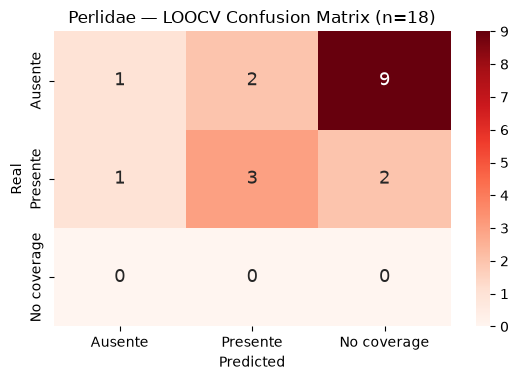

In [15]:
# Confusion matrix for the Perlidae LOOCV predictions
plot_cm(perlidae_loocv['y_true'], perlidae_loocv['y_pred'], perlidae_classes,
        "Perlidae — LOOCV Confusion Matrix (n=18)", "Reds")

## 6. LOOCV implementation — Model 3: Helicopsychidae

Reproduces the binary presence/absence fuzzy system of
[`01c_fuzzy_Helicopsychidae`](01c_fuzzy_Helicopsychidae.ipynb) under LOOCV on
`n = 18`, using the `Trichoptera` column as the response and the original `≥ 0.4999`
threshold.

In [16]:
# Build extended fuzzy I/O for Helicopsychidae (Trichoptera column)
helico_ants, helico_cons = make_io(CONFIG_EXTENDED, 'binary_output', 'Trichoptera')
HELICO_THR = 0.4999   # threshold used in 01c_fuzzy_Helicopsychidae

def helico_true(row):   return 'Presente' if row['Trichoptera'] == 1 else 'Ausente'
def helico_pred(out):   return 'Presente' if out >= HELICO_THR else 'Ausente'
def helico_consequent(row):
    return helico_cons['Presente'] if row['Trichoptera'] == 1 else helico_cons['Ausente']

# Run LOOCV for the Helicopsychidae model
helico_loocv = run_loocv(macro_df, input_cols, helico_ants, helico_cons, 'Trichoptera',
                         helico_consequent, helico_true, helico_pred)

helico_classes = ['Ausente', 'Presente']
helico_loocv_m = compute_metrics(helico_loocv['y_true'], helico_loocv['y_pred'], helico_classes)

print(f"Helicopsychidae LOOCV  accuracy={helico_loocv_m['accuracy']:.3f}  kappa={helico_loocv_m['kappa']:.3f}")
print(f"coverage failures: {len(helico_loocv['failed'])} of {len(macro_df)} "
      f"({100*len(helico_loocv['failed'])/len(macro_df):.0f}%)")
print("\nClassification report (LOOCV):")
report_labels = helico_classes + (['No coverage'] if 'No coverage' in helico_loocv['y_pred'] else [])
print(classification_report(helico_loocv['y_true'], helico_loocv['y_pred'],
                            labels=report_labels, zero_division=0))

Helicopsychidae LOOCV  accuracy=0.111  kappa=-0.079
coverage failures: 11 of 18 (61%)

Classification report (LOOCV):
              precision    recall  f1-score   support

     Ausente       0.67      0.13      0.22        15
    Presente       0.00      0.00      0.00         3
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.11        18
   macro avg       0.22      0.04      0.07        18
weighted avg       0.56      0.11      0.19        18



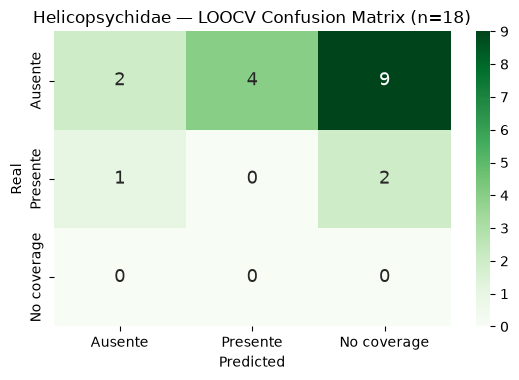

In [17]:
# Confusion matrix for the Helicopsychidae LOOCV predictions
plot_cm(helico_loocv['y_true'], helico_loocv['y_pred'], helico_classes,
        "Helicopsychidae — LOOCV Confusion Matrix (n=18)", "Greens")

## 7. Comparison table: LOOCV vs in-sample

To make the comparison self-contained and exact, the in-sample baseline is
*recomputed* here with `CONFIG_ORIGINAL` on the outlier-removed `n = 14` data,
reproducing the methodology of notebooks 01a/01b/01c (rules from all observations,
evaluated on the same observations). Precision, recall and F1 are **macro
averages** over the substantive classes; *Failed folds* counts coverage failures
(always 0 in sample, because every observation is covered by its own rule).

**A note on input representation.** The in-sample baseline reproduces the
originals *exactly*, including the fact that they entered each observation into the
inference engine as its dominant **linguistic category** (skfuzzy reads the label
as full membership in that set). The LOOCV instead feeds each held-out station its
**raw crisp measurements** (the protocol requested for this notebook), which is the
more natural test because it lets the fuzzy system use graded membership to
interpolate to an unseen point. The crisp representation is therefore the *kinder*
of the two for out-of-sample prediction; if anything it flatters the LOOCV relative
to a strict categorical lookup. This difference is called out again in the
Limitations.

In [18]:
# Reproduce the original n=14 sample by applying the IQR outlier rule (margin=2.5)
def remove_excessive_outliers(df, column, margin=2.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + margin * IQR)]

def clean_n14(df):
    out = df.copy()
    for column in ['DBO5', 'Turbiedad', 'Conductividad', 'OD', 'SDT']:
        out = remove_excessive_outliers(out, column, margin=2.5)
    return out

macro_n14 = clean_n14(macro_df)
bmwp_n14 = clean_n14(bmwp_df)
print("In-sample baseline sizes -> macro:", len(macro_n14), "| bmwp:", len(bmwp_n14))

In-sample baseline sizes -> macro: 14 | bmwp: 14


In [19]:
# In-sample baseline for BMWP using the ORIGINAL membership functions on n=14
o_bmwp_ants, o_bmwp_cons = make_io(CONFIG_ORIGINAL, 'bmwp_output', 'bmwp')
def o_bmwp_true(row): return categorize_label(row['BMWP'], o_bmwp_cons)
def o_bmwp_pred(out): return categorize_label(out, o_bmwp_cons)
def o_bmwp_cons_fn(row): return o_bmwp_cons[categorize_label(row['BMWP'], o_bmwp_cons)]
bmwp_insample = run_insample(bmwp_n14, input_cols, o_bmwp_ants, o_bmwp_cons, 'bmwp',
                             o_bmwp_cons_fn, o_bmwp_true, o_bmwp_pred)
bmwp_is_classes = [c for c in BMWP_ORDER if c in bmwp_insample['y_true']]
bmwp_insample_m = compute_metrics(bmwp_insample['y_true'], bmwp_insample['y_pred'], bmwp_is_classes)
rs_is, _ = spearmanr([bmwp_n14['BMWP'].iloc[i] for i in range(len(bmwp_n14))], bmwp_insample['crisp'])

# In-sample baseline for Perlidae (original MFs, n=14)
o_perl_ants, o_perl_cons = make_io(CONFIG_ORIGINAL, 'binary_output', 'Perlidae')
def o_perl_true(row): return 'Presente' if row['Perlidae'] == 1 else 'Ausente'
def o_perl_pred(out): return 'Presente' if out >= PERLIDAE_THR else 'Ausente'
def o_perl_cons_fn(row): return o_perl_cons['Presente'] if row['Perlidae'] == 1 else o_perl_cons['Ausente']
perlidae_insample = run_insample(macro_n14, input_cols, o_perl_ants, o_perl_cons, 'Perlidae',
                                 o_perl_cons_fn, o_perl_true, o_perl_pred)
perlidae_insample_m = compute_metrics(perlidae_insample['y_true'], perlidae_insample['y_pred'],
                                      ['Ausente', 'Presente'])

# In-sample baseline for Helicopsychidae (original MFs, n=14)
o_heli_ants, o_heli_cons = make_io(CONFIG_ORIGINAL, 'binary_output', 'Trichoptera')
def o_heli_true(row): return 'Presente' if row['Trichoptera'] == 1 else 'Ausente'
def o_heli_pred(out): return 'Presente' if out >= HELICO_THR else 'Ausente'
def o_heli_cons_fn(row): return o_heli_cons['Presente'] if row['Trichoptera'] == 1 else o_heli_cons['Ausente']
helico_insample = run_insample(macro_n14, input_cols, o_heli_ants, o_heli_cons, 'Trichoptera',
                               o_heli_cons_fn, o_heli_true, o_heli_pred)
helico_insample_m = compute_metrics(helico_insample['y_true'], helico_insample['y_pred'],
                                    ['Ausente', 'Presente'])

print(f"BMWP in-sample            acc={bmwp_insample_m['accuracy']:.3f} kappa={bmwp_insample_m['kappa']:.3f} rs={rs_is:.3f}")
print(f"Perlidae in-sample        acc={perlidae_insample_m['accuracy']:.3f} kappa={perlidae_insample_m['kappa']:.3f}")
print(f"Helicopsychidae in-sample acc={helico_insample_m['accuracy']:.3f} kappa={helico_insample_m['kappa']:.3f}")

BMWP in-sample            acc=0.929 kappa=0.878 rs=0.827
Perlidae in-sample        acc=0.929 kappa=0.857
Helicopsychidae in-sample acc=0.929 kappa=0.811


In [20]:
# Assemble the publication-ready comparison table
def row(model, evaluation, n, m, failed, n_total):
    return {'Model': model, 'Evaluation': evaluation, 'n': n,
            'Precision': round(m['precision'], 3), 'Recall': round(m['recall'], 3),
            'F1': round(m['f1'], 3), 'Accuracy': round(m['accuracy'], 3),
            'Kappa': round(m['kappa'], 3), 'Failed folds': f"{failed}/{n_total}"}

comparison = pd.DataFrame([
    row('BMWP', 'In-sample', 14, bmwp_insample_m, 0, 14),
    row('BMWP', 'LOOCV', 18, bmwp_loocv_m, len(bmwp_loocv['failed']), 18),
    row('Perlidae', 'In-sample', 14, perlidae_insample_m, 0, 14),
    row('Perlidae', 'LOOCV', 18, perlidae_loocv_m, len(perlidae_loocv['failed']), 18),
    row('Helicopsychidae', 'In-sample', 14, helico_insample_m, 0, 14),
    row('Helicopsychidae', 'LOOCV', 18, helico_loocv_m, len(helico_loocv['failed']), 18),
])
comparison

,Model,Evaluation,n,Precision,Recall,F1,Accuracy,Kappa,Failed folds
0,BMWP,In-sample,14,0.778,0.800,0.788,0.929,0.878,0/14
1,BMWP,LOOCV,18,0.133,0.100,0.114,0.222,0.077,11/18
2,Perlidae,In-sample,14,0.929,0.938,0.928,0.929,0.857,0/14
3,Perlidae,LOOCV,18,0.550,0.292,0.344,0.222,0.067,11/18
4,Helicopsychidae,In-sample,14,0.875,0.955,0.905,0.929,0.811,0/14
5,Helicopsychidae,LOOCV,18,0.333,0.067,0.111,0.111,-0.079,11/18


In [21]:
# Persist the comparison table for the report
comparison.to_csv("../../outputs/fuzzy_loocv_vs_insample.csv", index=False)
print("Saved: outputs/fuzzy_loocv_vs_insample.csv")
print(comparison.to_string(index=False))

Saved: outputs/fuzzy_loocv_vs_insample.csv
          Model Evaluation  n  Precision  Recall    F1  Accuracy  Kappa Failed folds
           BMWP  In-sample 14      0.778   0.800 0.788     0.929  0.878         0/14
           BMWP      LOOCV 18      0.133   0.100 0.114     0.222  0.077        11/18
       Perlidae  In-sample 14      0.929   0.938 0.928     0.929  0.857         0/14
       Perlidae      LOOCV 18      0.550   0.292 0.344     0.222  0.067        11/18
Helicopsychidae  In-sample 14      0.875   0.955 0.905     0.929  0.811         0/14
Helicopsychidae      LOOCV 18      0.333   0.067 0.111     0.111 -0.079        11/18


## 8. Discussion of results

**LOOCV metrics collapse relative to in-sample.** All three models score in-sample
accuracy ≈ 0.93 (Kappa 0.81–0.88), but under LOOCV accuracy falls to **0.22 for
BMWP, 0.22 for Perlidae and 0.11 for Helicopsychidae**, with Kappa values of
**0.08, 0.07 and −0.08** — i.e. statistically indistinguishable from chance, and
slightly *worse* than chance for Helicopsychidae. The in-sample fuzzy systems
simply memorise the data: each observation is covered by a rule built from that
exact observation, so the apparent skill is fit, not generalisation. The drop is
the textbook signature of an over-fit look-up model.

**Coverage failures are the key diagnostic.** Each rule is a conjunction of five
three-level predictors, so the rule base is effectively a sparse look-up table over
up to 3⁵ = 243 category combinations. With only 17 training rules per fold,
**11 of 18 held-out stations (61%) fall into a category combination that no rule
covers**, and the engine cannot produce an output (`No coverage`) — in every model.
Ecologically this means the system learned specific *site fingerprints* rather than
transferable environment→biology relationships: a station even slightly different
from the training set is unclassifiable.

**The cross-model picture changes — fuzzy logic does not win out-of-sample.** Put on
the same out-of-sample footing as the other models:

| Model (target) | Out-of-sample accuracy | Kappa |
|---|---|---|
| Fuzzy BMWP (LOOCV) | 0.22 | 0.08 |
| Fuzzy Perlidae (LOOCV) | 0.22 | 0.07 |
| Fuzzy Helicopsychidae (LOOCV) | 0.11 | −0.08 |
| Logistic Perlidae (LOOCV) | 0.61 | 0.32 |
| Logistic Helicopsychidae (LOOCV) | 0.44 | 0.14 |
| Tree Perlidae (held-out test, n=6) | 0.83 | — |
| Tree Helicopsychidae (held-out test, n=6) | 0.83 | — |

The logistic and tree models were *already* validated out-of-sample, so their
(modest) numbers are honest. The fuzzy models' apparent parity/superiority existed
only in sample; once cross-validated they are the **worst** of the three families,
not the best.

**Spearman correlation for BMWP.** The headline `rs = 0.827` from the simulation
notebook is an in-sample figure and is reproduced here as such. Under LOOCV the rank
correlation drops to **rs = 0.143 (p = 0.76, not significant)**, and it is computed
over only the **7 folds that produced any output** — it silently ignores the 11
stations the model could not classify. It is therefore *not* a defensible
stand-alone performance indicator; read on its own it badly overstates the model,
and it must always be reported next to the 61% coverage-failure rate.

## 9. Limitations

- **Residual in-sample dependency.** LOOCV here cross-validates only the *rule
  base*. The membership-function breakpoints were fixed a priori (from the
  literature / expert criteria, and widened using the full-sample range). A fully
  honest protocol would re-derive every membership function inside each fold; the
  values reported here are therefore still mildly optimistic.

- **Spatial dependence.** The observations are monitoring stations along a single
  river, so they are not independent — upstream/downstream stations share water
  masses and gradients. Standard LOOCV assumes exchangeable samples; a
  spatial/blocked cross-validation (e.g. leaving out a whole reach) would be more
  rigorous, but is not feasible with `n = 18`.

- **Sample-size asymmetry (n = 18 here vs n = 14 originally).** The full sample was
  used so the fuzzy models match the `n = 18` used by the logistic, tree and
  negative-binomial models, making the cross-model comparison fair. The cost is
  that the LOOCV (`n = 18`) and the reproduced in-sample baseline (`n = 14`) differ
  in both evaluation regime *and* sample size; the table should be read as
  in-sample-fit-at-n14 vs honest-generalisation-at-n18, not as a controlled
  one-variable change.

- **Input representation differs between the two regimes.** The in-sample baseline
  enters observations as linguistic categories (to reproduce the originals exactly),
  whereas the LOOCV enters raw crisp values (the requested protocol). The crisp
  representation is the more favourable one for out-of-sample prediction, so the
  LOOCV collapse reported here is *not* an artefact of a harsher input encoding — a
  strict categorical LOOCV performs even worse (near-total coverage failure).

- **Tiny, imbalanced data.** With 18 observations (and as few as 3 positives for
  Helicopsychidae), every metric has very wide uncertainty, single observations can
  flip a class score, and per-class precision/recall for rare classes are
  essentially anecdotal. All results are indicative, not conclusive.